🔹 Chargement des données (avec pandas)

Import

In [1]:
import pandas as ps
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

 Lire le fichier CSV

In [2]:
df= ps.read_csv('../data/raw/appartements-data-db.csv')

Afficher les premières lignes (df.head())

price variable target
les autres featres


In [3]:
df.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,equipment,link
0,CMN-MA-1752 - Appartement à vendre à Palmier,2 000 000 DH,Casablanca,NaN,2.0,2.0,168.0,Ascenseur/Balcon/Parking/Terrasse,https://www.avito.ma/fr/palmier/appartements/C...
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1 195 000 DH,Casablanca,NaN,2.0,2.0,98.0,Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...,https://www.avito.ma/fr/hay_hassani/appartemen...
2,Appartement à vendre 81 m² à Dar Bouazza,1 350 000 DH,Dar Bouazza,1.0,2.0,2.0,81.0,Ascenseur/Balcon/Chauffage/Climatisation/Conci...,https://www.avito.ma/fr/dar_bouazza/appartemen...
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900 000 DH,Casablanca,NaN,1.0,1.0,56.0,Ascenseur/Chauffage/Climatisation/Cuisine Équi...,https://www.avito.ma/fr/centre_ville/apparteme...
4,Appartement à Rabat Agdal,3 100 000 DH,Rabat,2.0,3.0,2.0,200.0,Ascenseur/Balcon/Concierge/Parking/Sécurité,https://www.avito.ma/fr/agdal/appartements/App...


 Vérifier la structure (df.info(), df.shape, df.columns)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1773 entries, 0 to 1772
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1772 non-null   object 
 1   price         1490 non-null   object 
 2   city_name     1772 non-null   object 
 3   salon         1620 non-null   float64
 4   nb_rooms      1490 non-null   float64
 5   nb_baths      1480 non-null   float64
 6   surface_area  1742 non-null   float64
 7   equipment     1402 non-null   object 
 8   link          1773 non-null   object 
dtypes: float64(4), object(5)
memory usage: 124.8+ KB
None


In [5]:
print(df.shape)

(1773, 9)


In [6]:
print(df.columns)

Index(['title', 'price', 'city_name', 'salon', 'nb_rooms', 'nb_baths',
       'surface_area', 'equipment', 'link'],
      dtype='object')


Détecter les types (object, float64, etc.)


In [7]:
print(df.dtypes)

title            object
price            object
city_name        object
salon           float64
nb_rooms        float64
nb_baths        float64
surface_area    float64
equipment        object
link             object
dtype: object


🔹 Analyse exploratoire (EDA)

 Résumer les statistiques (df.describe())

In [8]:
print(df.describe())

             salon     nb_rooms     nb_baths   surface_area
count  1620.000000  1490.000000  1480.000000    1742.000000
mean      1.267284     2.379195     2.307432     174.933410
std       0.557539     0.667159     7.629128    2969.500693
min       0.000000     1.000000     0.000000       1.000000
25%       1.000000     2.000000     1.000000      71.000000
50%       1.000000     2.000000     2.000000      89.000000
75%       1.000000     3.000000     2.000000     114.750000
max       8.000000     7.000000   134.000000  123456.000000


 Identifier les valeurs manquantes (df.isnull().sum())

In [9]:
print(df.isnull().sum())

title             1
price           283
city_name         1
salon           153
nb_rooms        283
nb_baths        293
surface_area     31
equipment       371
link              0
dtype: int64


Identifier les doublons (df.duplicated().sum())

In [10]:
print(df.duplicated().sum())

41


🔹  Étude des variables numériques

 Visualiser la distribution (hist, boxplot)

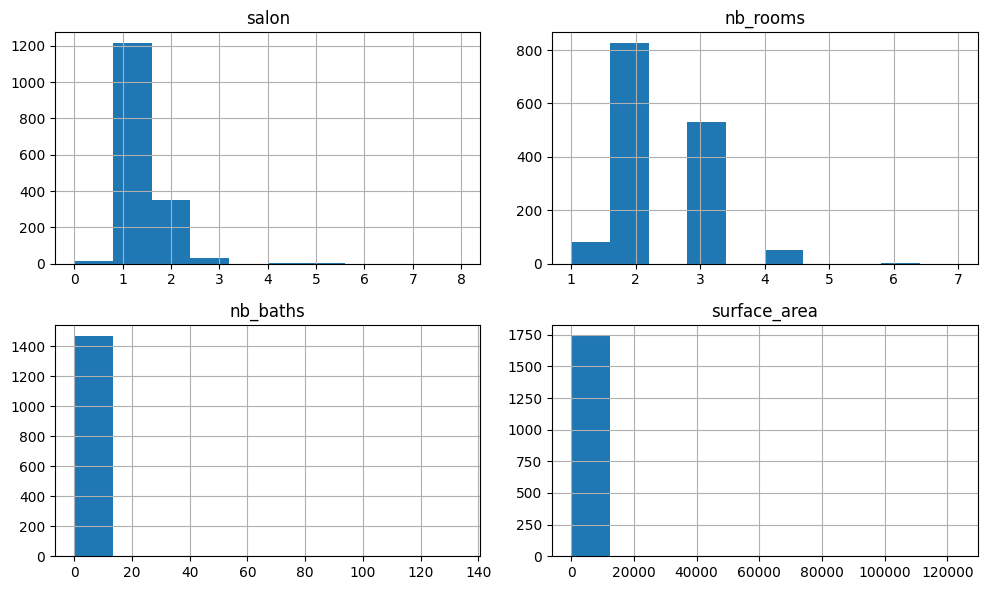

In [11]:
df.select_dtypes(include='number').hist(bins=10, figsize=(10, 6))
plt.tight_layout()
plt.show()

Détecter les outliers (ex: prix trop élevés)

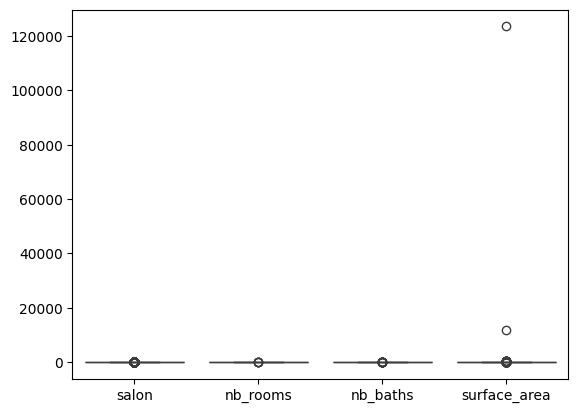

In [12]:
sns.boxplot(df)
plt.show()

Vérifier la corrélation avec price

correct valeur et convert price from object to float

In [13]:
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True).astype(float)

 Créer une matrice de corrélation (df.corr())

In [14]:
corr_matrix = df.corr(numeric_only=True)
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr)

price           1.000000
surface_area    0.471631
nb_rooms        0.261319
salon           0.226761
nb_baths        0.006025
Name: price, dtype: float64


 Visualiser avec une heatmap (avec seaborn)

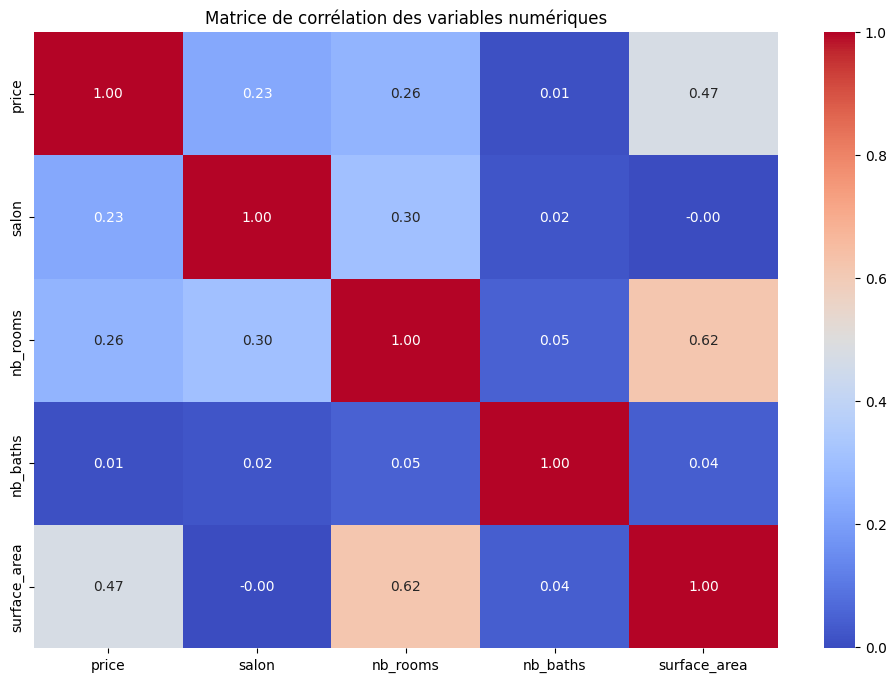

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

 Identifier les variables utiles (corrélation > 0.15)

In [ ]:
cor_with_price = corr_matrix['price'].sort_values(ascending=False)
useful_features = cor_with_price[cor_with_price > 0.15].drop('price')  

print("Variables utiles (corrélation > 0.15 avec 'price'):")
print(useful_features)

Variables utiles (corrélation > 0.15 avec 'price'):
surface_area    0.471631
nb_rooms        0.261319
salon           0.226761
Name: price, dtype: float64


In [17]:
df.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,equipment,link
0,CMN-MA-1752 - Appartement à vendre à Palmier,2000000.0,Casablanca,NaN,2.0,2.0,168.0,Ascenseur/Balcon/Parking/Terrasse,https://www.avito.ma/fr/palmier/appartements/C...
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,Casablanca,NaN,2.0,2.0,98.0,Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...,https://www.avito.ma/fr/hay_hassani/appartemen...
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,Dar Bouazza,1.0,2.0,2.0,81.0,Ascenseur/Balcon/Chauffage/Climatisation/Conci...,https://www.avito.ma/fr/dar_bouazza/appartemen...
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,Casablanca,NaN,1.0,1.0,56.0,Ascenseur/Chauffage/Climatisation/Cuisine Équi...,https://www.avito.ma/fr/centre_ville/apparteme...
4,Appartement à Rabat Agdal,3100000.0,Rabat,2.0,3.0,2.0,200.0,Ascenseur/Balcon/Concierge/Parking/Sécurité,https://www.avito.ma/fr/agdal/appartements/App...


🔹 Nettoyage & Transformation

 Extraire les équipements → colonnes booléennes via str.get_dummies()

In [18]:
equipment_dummies = df['equipment'].str.get_dummies(sep='/')



Ajouter les colonnes extraites dans le DataFrame 

In [19]:
df = ps.concat([df, equipment_dummies], axis=1)


supp link et equipment

In [20]:
df = df.drop(['link','equipment'],axis=1)

In [21]:
df.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,Ascenseur,Balcon,Chauffage,Climatisation,Concierge,Cuisine Équipée,Duplex,Meublé,Parking,Sécurité,Terrasse
0,CMN-MA-1752 - Appartement à vendre à Palmier,2000000.0,Casablanca,NaN,2.0,2.0,168.0,1,1,0,0,0,0,0,0,1,0,1
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,Casablanca,NaN,2.0,2.0,98.0,1,1,1,1,0,1,0,0,1,0,0
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,Dar Bouazza,1.0,2.0,2.0,81.0,1,1,1,1,1,1,1,0,1,1,1
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,Casablanca,NaN,1.0,1.0,56.0,1,0,1,1,0,1,0,1,1,1,1
4,Appartement à Rabat Agdal,3100000.0,Rabat,2.0,3.0,2.0,200.0,1,1,0,0,1,0,0,0,1,1,0


 Harmoniser les noms de villes (city_name) : arabe → français

In [22]:
print(df['city_name'].unique())

['Casablanca' 'Dar Bouazza' 'Rabat' 'Marrakech' 'Asilah' 'Bouskoura'
 'Kénitra' 'Mohammedia' 'Agadir' 'Tamesna' 'Salé' 'Had Soualem' 'Temara'
 'Benslimane' 'Tanger' 'Bouznika' 'Meknès' 'Fès' 'El Jadida'
 'El Mansouria' 'Martil' 'الدار البيضاء' 'Fnideq' 'Tétouan' 'Saidia'
 'Nouaceur' 'القنيطرة' 'Tamaris' 'طنجة' 'Cabo Negro'
 'Sidi Allal El Bahraoui' 'Béni Mellal' 'أكادير' nan 'Essaouira' 'Mehdia'
 'المحمدية' 'Oujda' 'Oued Laou' 'Dcheira' 'Sidi Rahal' 'Deroua' 'مراكش'
 'Ain Attig' 'Safi' 'الرباط' 'Inzegan' 'Ifrane' 'Dakhla'
 'Dcheïra El Jihadia' 'Taghazout' 'Sidi Bouknadel' 'Skhirat' 'Khouribga'
 'Berkane' 'Mers El Kheir' 'Berrechid' 'Tiznit' 'Agadir Melloul' 'Nador'
 'El Menzeh' 'Bni Ansar' 'Mdiq' 'Tit Mellil' 'Souk El Arbaa' 'Biougra'
 'Settat' 'Ain Aouda' 'Taza' 'Khemisset' 'Oued Zem' 'Sefrou' 'Merzouga'
 'El Hajeb' 'Selouane' 'Taounate' 'Sidi Bennour' 'El Ksiba']


In [23]:
ville_map = {
    'الدار البيضاء': 'Casablanca',
    'الرباط': 'Rabat',
    'فاس': 'Fès',
    'مراكش': 'Marrakech',
    'طنجة': 'Tanger',
    'أكادير': 'Agadir',
    'المحمدية': 'Mohammedia',
    'القنيطرة': 'Kénitra'
}

In [24]:
df.city_name = df.city_name.replace(ville_map)

In [25]:
print(df['city_name'].unique())

['Casablanca' 'Dar Bouazza' 'Rabat' 'Marrakech' 'Asilah' 'Bouskoura'
 'Kénitra' 'Mohammedia' 'Agadir' 'Tamesna' 'Salé' 'Had Soualem' 'Temara'
 'Benslimane' 'Tanger' 'Bouznika' 'Meknès' 'Fès' 'El Jadida'
 'El Mansouria' 'Martil' 'Fnideq' 'Tétouan' 'Saidia' 'Nouaceur' 'Tamaris'
 'Cabo Negro' 'Sidi Allal El Bahraoui' 'Béni Mellal' nan 'Essaouira'
 'Mehdia' 'Oujda' 'Oued Laou' 'Dcheira' 'Sidi Rahal' 'Deroua' 'Ain Attig'
 'Safi' 'Inzegan' 'Ifrane' 'Dakhla' 'Dcheïra El Jihadia' 'Taghazout'
 'Sidi Bouknadel' 'Skhirat' 'Khouribga' 'Berkane' 'Mers El Kheir'
 'Berrechid' 'Tiznit' 'Agadir Melloul' 'Nador' 'El Menzeh' 'Bni Ansar'
 'Mdiq' 'Tit Mellil' 'Souk El Arbaa' 'Biougra' 'Settat' 'Ain Aouda' 'Taza'
 'Khemisset' 'Oued Zem' 'Sefrou' 'Merzouga' 'El Hajeb' 'Selouane'
 'Taounate' 'Sidi Bennour' 'El Ksiba']


 Remplacer les valeurs manquantes dans city_name par "Unknown"

In [26]:
df.city_name=df.city_name.fillna('Unknown')

In [27]:
df.city_name.unique()

array(['Casablanca', 'Dar Bouazza', 'Rabat', 'Marrakech', 'Asilah',
       'Bouskoura', 'Kénitra', 'Mohammedia', 'Agadir', 'Tamesna', 'Salé',
       'Had Soualem', 'Temara', 'Benslimane', 'Tanger', 'Bouznika',
       'Meknès', 'Fès', 'El Jadida', 'El Mansouria', 'Martil', 'Fnideq',
       'Tétouan', 'Saidia', 'Nouaceur', 'Tamaris', 'Cabo Negro',
       'Sidi Allal El Bahraoui', 'Béni Mellal', 'Unknown', 'Essaouira',
       'Mehdia', 'Oujda', 'Oued Laou', 'Dcheira', 'Sidi Rahal', 'Deroua',
       'Ain Attig', 'Safi', 'Inzegan', 'Ifrane', 'Dakhla',
       'Dcheïra El Jihadia', 'Taghazout', 'Sidi Bouknadel', 'Skhirat',
       'Khouribga', 'Berkane', 'Mers El Kheir', 'Berrechid', 'Tiznit',
       'Agadir Melloul', 'Nador', 'El Menzeh', 'Bni Ansar', 'Mdiq',
       'Tit Mellil', 'Souk El Arbaa', 'Biougra', 'Settat', 'Ain Aouda',
       'Taza', 'Khemisset', 'Oued Zem', 'Sefrou', 'Merzouga', 'El Hajeb',
       'Selouane', 'Taounate', 'Sidi Bennour', 'El Ksiba'], dtype=object)

🔹  Gestion des valeurs manquantes

Colonnes numériques → imputation par médiane

In [28]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

Colonnes catégorielles → imputation par "Unknown"

In [29]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

🔹 Détection & suppression des valeurs aberrantes (outliers)

In [ ]:
def remv_outs_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <=upper_bound)]                                            
df=remv_outs_IQR(df,'price')
df=remv_outs_IQR(df,'surface_area')

🔹Encodage des variables catégorielles

In [41]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()

df['city_name_encoded'] = label_encoder.fit_transform(df['city_name'])

print(df[['city_name', 'city_name_encoded']].head())

     city_name  city_name_encoded
1   Casablanca                 13
2  Dar Bouazza                 15
3   Casablanca                 13
6    Marrakech                 32
7   Casablanca                 13


🔹 Mise à l’échelle des variables numériques

In [43]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [44]:
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [45]:
print(df[numeric_cols].head())

      price  salon  nb_rooms  nb_baths  surface_area  Ascenseur  Balcon  \
1  0.715563  0.125  0.333333  0.014925      0.589552        1.0     1.0   
2  0.808379  0.125  0.333333  0.014925      0.462687        1.0     1.0   
3  0.538912  0.125  0.000000  0.007463      0.276119        1.0     0.0   
6  0.455078  0.125  0.666667  0.022388      0.589552        1.0     1.0   
7  0.473043  0.125  0.666667  0.014925      0.402985        0.0     0.0   

   Chauffage  Climatisation  Concierge  Cuisine Équipée  Duplex  Meublé  \
1        1.0            1.0        0.0              1.0     0.0     0.0   
2        1.0            1.0        1.0              1.0     1.0     0.0   
3        1.0            1.0        0.0              1.0     0.0     1.0   
6        0.0            0.0        1.0              1.0     0.0     0.0   
7        0.0            0.0        0.0              1.0     0.0     0.0   

   Parking  Sécurité  Terrasse  city_name_encoded  
1      1.0       0.0       0.0           0.200

export csv file 

In [47]:
df.to_csv('../data/processed/clean_data.csv')